# Statistics 
" Statistics is the discipline of collecting, analyzing, interpreting, and presenting data to identify patterns and inform decision-making. "

In [1]:
# lets say we have marks of students so how will we draw points from this 
marks  =  [45, 56, 67, 78, 89, 90, 56, 67, 78, 56]

from the above list we can have many questions like : 
1. Average marks ?
2. Common marks in my list ?
3. Middle student score ?

In [2]:
#imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Mean 
Mean is defined as the Sum of all 'n' observations / Total number of observations 

$$
\text{Mean} = \frac{\sum x}{n}
$$

Where:

- $\sum x$ = Sum of all observations
- $n$ = Number of observations

In [3]:
marks = np.array([10,20,30,40,50])
mean = np.mean(marks)
print(mean)

30.0


for this case the mean is totally reliable and useful in getting the avg but for the same scenario if we update the array to have one outliers or just one single large value the avg suddendly spikes irrelevant with the data

In [4]:
marks = np.array([10,20,30,40,1000])
print(np.mean(marks))

220.0


Earlier the mean suggested that If everyone's marks were distributed equally, each student would get 30 marks.
And now , the question arises that did a student even score 220 ? No, One extreme value (1000) distorted the average which is called as an Outlier

### Outlier
By definition, it is an extreme endpoint (a value far away from the rest of the data).
By effect, it is the value that distorts the average (the mean).

## Median
Median is the middle observation in a sorted dataset.
For odd number of observations:
$$
Median = Middle\ Value
$$
For even number of observations:
$$
Median =
\frac{
Middle_1 + Middle_2
}{2}
$$

In [5]:
eg = [10,20,30,35,40,50]
print(np.median(marks))

30.0


In [6]:
# In case of an outlier
eg = [10,20,30,35,40,1000]
print(np.median(marks))

30.0


Median didn't get affected. This is why salaries are often reported using median instead of mean.

## Mode

Mode is the observation with the highest frequency.

$$
Mode = Most\ Frequent\ Value
$$

In [7]:
marks = pd.Series([10,20,20,20,30,40])
print(marks.mode())

0    20
dtype: int64


Mode tells us : The most common value. Useful in:
1. Product sizes
2. Most purchased item
3. Most common age group

Summary of the day : 
| Measure | Meaning | Affected by Outliers? |
|----------|----------|----------------------|
| Mean | Average | Yes |
| Median | Middle Value | No |
| Mode | Most Frequent Value | No |

In [8]:
data = {
    "Marks":[45, 56, 67, 78, 89, 90, 56, 67, 78, 56,500]
}

df = pd.DataFrame(data)

print("Mean:",df["Marks"].mean())
print("Median:",df["Marks"].median())
print("Mode:",df["Marks"].mode()[0])

Mean: 107.45454545454545
Median: 67.0
Mode: 56


> When should you use Median instead of Mean?

When data contains outliers or is skewed. Median is more robust because extreme values do not affect it significantly.

from the above study, we can conclude that a distorted mean can make our analysis go in the wrong direction say for this case, lets consider marks of students in different classes 

In [9]:
marks_a = [48, 49, 50, 51, 52]
print(np.mean(marks_a))
marks_b = [10, 20, 50, 80, 90]
print(np.mean(marks_b))

50.0
50.0


As we can see that the mean for both the classes was same but there is significant difference in the students performance So we need a measure of spread.That's Variance.

## Variance

Variance measures the average squared distance from the mean.

$$
Variance = \frac{\sum (x-\bar{x})^2}{n}
$$

Where:

- $x$ = Observation
- $\bar{x}$ = Mean
- $n$ = Number of observations

Question : when we need to measure the spread of the data then why don't we directly subtract it from mean. 

In [10]:
datalist = [10,20,30,40,50]
print(np.mean(datalist))

30.0


here's why we square the values because we might get negatives and some times even the difference might cancel out if negative values are present.

In [11]:
print(datalist[1] - np.mean(datalist))
ValueMinusMean_for_datalist = [-20,-10,0,10,20]

-10.0


In [12]:
print(np.sum(ValueMinusMean_for_datalist))

0


Turns out to be zero can't calculate variance hence squared

In [13]:
np.var(datalist)

np.float64(200.0)

Problem with variance : now if we use variance on marks it becomes marks². This never feels intuitive and nobody says variance is 200 marks².So, we use standard deviation 

## Standard Deviation
Standard deviation is the square root of variance.
$$
\sigma = \sqrt{Variance}
$$
By effect, it simply tells the average distance of a value from the mean.

In [14]:
# from above case, the variance was 200.
variance = 200
std_dev = np.sqrt(variance)
print("By sqrt method :",std_dev)
print("By direct function call : ",np.std(datalist))

By sqrt method : 14.142135623730951
By direct function call :  14.142135623730951


Now, its a more clearer picture to draw insight from and one can interpret that, Most marks are roughly 14 points away from the mean.

In [15]:
marks = pd.Series([10,20,30,40,50])
print("Variance:",marks.var())
print("Standard Deviation:",marks.std())

Variance: 250.0
Standard Deviation: 15.811388300841896


Summary of the day :
- Variance tells us the spread of the data. But, uses squared units.
- Small Variance: Data points are close to the mean and Large Variance: Data points are far from the mean.
- Standard Deviation is the square root of variance. Hence , is easier to interpret because it uses the original unit.
- Low Standard Deviation: consistency. High Standard Deviation: variability.

> Q: Why is Standard Deviation preferred over Variance?

Variance is measured in squared units, making interpretation difficult. Standard Deviation is in the same units as the original data, making it easier to understand and communicate.

>

--- ---

Till now what we learned was how much is the data spread ?? . But here's the main question if spread then where is the spread exactly in my data ???

lets understand this by a test case : Consider a class of 100 students .
1. By checking the mean , median and mode we are limited to only know what is the spread of marks in my data ?.
2. At that instance we cannot tell exactly where the top 25 students start

To solve this we need *Quartiles* . If we sort/arrange the data in ascending order then we can locate exactly the First 25%, First 50% and First 75%

>

## Quartiles

Quartiles divide an ordered dataset into four equal parts.

There are three quartiles:

- **First Quartile (Q1):** 25% of observations lie below this value.
- **Second Quartile (Q2):** 50% of observations lie below this value. It is also called the **Median**.
- **Third Quartile (Q3):** 75% of observations lie below this value.

The dataset is divided as:

$$
\text{Minimum} \quad | \quad Q_1 \quad | \quad Q_2 \quad | \quad Q_3 \quad | \quad \text{Maximum}
$$

In [16]:
marks = np.array([10,20,30,40,50,60,70,80])
q1 = np.percentile(marks,25)
q2 = np.percentile(marks,50)
q3 = np.percentile(marks,75)
print("Q1 :",q1, end = ", ")
print("Q2 :",q2, end = ", ")
print("Q3 :",q3, end = ". ")

Q1 : 27.5, Q2 : 45.0, Q3 : 62.5. 

In [17]:
# In pandas 
marks = pd.Series([10,20,30,40,50,60,70,80])
print(marks.quantile(0.25))
print(marks.quantile(0.50))
print(marks.quantile(0.75))

27.5
45.0
62.5


Quartiles are also called as positional measures.
They form the foundation for Percentiles, Interquartile Range (IQR), and Box Plots.

Quartiles divide the data in 4 parts. But some times there might be a need for a precise information. say 10 lakh students are appearing for an exam here quartiles are not enough for ranking purposes as the data is to be divided in to multiple small parts like Top 10% ,Top 5% ,Top 1% or Bottom 20% ,Bottom 40%.
Here arises the need of Percentiles

>

## Percentiles
A percentile divides an ordered dataset into 100 equal parts.
The **k-th percentile** is the value below which **k%** of the observations lie.
Examples:
- 25th Percentile = First Quartile (Q1)
- 50th Percentile = Median (Q2)
- 75th Percentile = Third Quartile (Q3)
  
Thus, Relationship of quartile with percentile is as follows : 

$$
Q_1 = P_{25}
$$

$$
Q_2 = P_{50}
$$

$$
Q_3 = P_{75}
$$

In [18]:
# In Numpy
marks = np.array([10,20,30,40,50,60,70,80,90,100])
print("25th Percentile :", np.percentile(marks,25))
print("50th Percentile :", np.percentile(marks,50))
print("75th Percentile :", np.percentile(marks,75))
print("90th Percentile :", np.percentile(marks,90))

25th Percentile : 32.5
50th Percentile : 55.0
75th Percentile : 77.5
90th Percentile : 91.0


In [19]:
# In pandas
marks = pd.Series([10,20,30,40,50,60,70,80,90,100])
print(marks.quantile(0.25))
print(marks.quantile(0.50))
print(marks.quantile(0.75))
print(marks.quantile(0.90))

32.5
55.0
77.5
91.0


Interpretation , suppose 90th Percentile = 91
This means ,90% of the observations are less than or equal to 91.
> It does NOT mean the observation scored 91% marks.

>

> Q1. Are Quartiles and Percentiles different?

Yes,Quartiles divide the dataset into 4 equal parts and Percentiles divide the dataset into 100 equal parts.
Quartiles are simply specific percentiles:
* Q1 = 25th Percentile
* Q2 = 50th Percentile
* Q3 = 75th Percentile

-------

>

We saw two important above, Quartiles and Percentiles, they show where the spread of data is actually located. But then there is this question :

> **How can we measure the spread of the data without letting extreme values (outliers) distort our result?**

If we calculate the **Range**, we get
$$
Range = Maximum - Minimum 
$$

But range often gets disturbed/affected by Outliers.
So instead of considering the entire dataset, statisticians asked a better question :
> **"What if we ignore the extreme 25% of observations on both ends and focus only on the middle 50% of the data?"**

The spread of this middle 50% is called the **Interquartile Range (IQR).**
Because it ignores extreme values, IQR is considered an **robust measure of spread** 

>

## Interquartile Range (IQR)

The Interquartile Range measures the spread of the middle 50% of the data.

It is calculated as:

$$
IQR = Q_3 - Q_1
$$

Where:

- $Q_1$ = First Quartile (25th Percentile)
- $Q_3$ = Third Quartile (75th Percentile)

The Interquartile Range is resistant to outliers because it ignores the lowest 25% and highest 25% of the observations.

In [20]:
# In Pandas
marks = pd.Series([10,20,30,40,50,60,70,80])

q1 = marks.quantile(0.25)
q3 = marks.quantile(0.75)
iqr = q3 - q1
print("Q1 :",q1)
print("Q3 :",q3)
print("IQR :",iqr)

Q1 : 27.5
Q3 : 62.5
IQR : 35.0


In [21]:
# In numpy
marks = np.array([10,20,30,40,50,60,70,80])

q1 = np.percentile(marks,25)
q3 = np.percentile(marks,75)
iqr = q3 - q1
print("Q1 :",q1)
print("Q3 :",q3)
print("IQR :",iqr)

Q1 : 27.5
Q3 : 62.5
IQR : 35.0


>

> Q1. Why is IQR preferred over Range?

Range depends only on the minimum and maximum values, so it is highly affected by outliers. IQR focuses on the middle 50% of the data, making it a robust measure of spread.

> Q2. What does a small IQR indicate?

A small IQR indicates that the middle 50% of observations are closely packed together, showing low variability.

> Q3. What does a large IQR indicate?

A large IQR indicates that the middle 50% of observations are widely spread, showing high variability.

>

____

What we saw till now in statistics, summarized the data dispersion, outliers and center of the data.
But if an Data Analyst or Data Scientist has to understand these hidden points in data, will they calculate these points one by one.
**No** there is a method to this in just 5 seconds to get the 5 point summary by using the summary graph. 

## Box Plot (Box-and-Whisker Plot)
A Box Plot is a graphical representation of a dataset based on the five-number summary : 
> **minimum, first quartile (Q1), median, third quartile (Q3), and maximum**

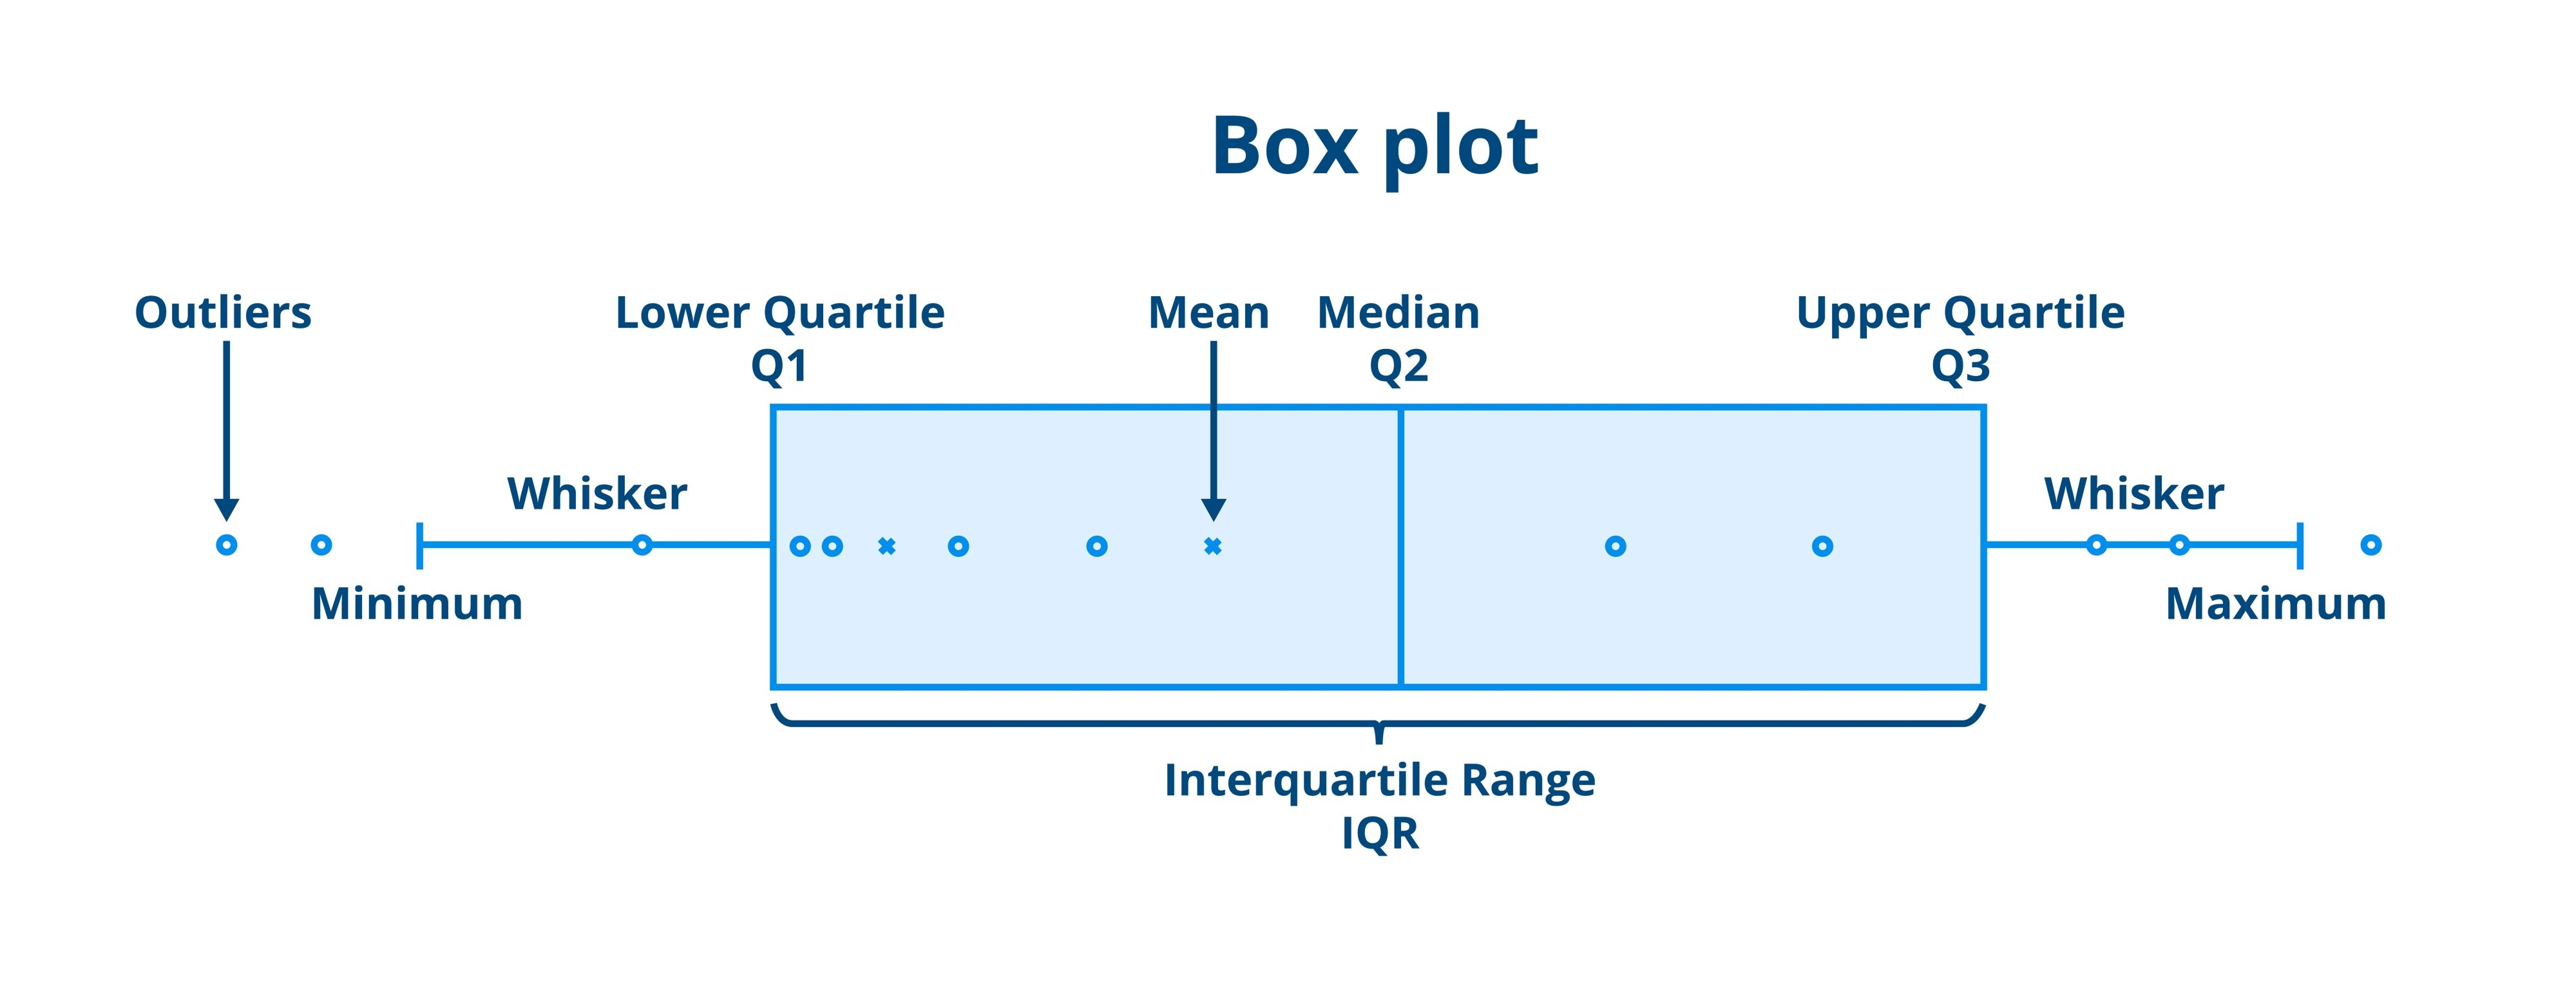

## Outlier Detection using IQR
The lower and upper limits are calculated as:
$$
Lower\ Fence = Q_1 - 1.5(IQR)
$$
$$
Upper\ Fence = Q_3 + 1.5(IQR)
$$
Where,
$$
IQR = Q_3 - Q_1
$$

Any observation outside these limits is considered a potential outlier.

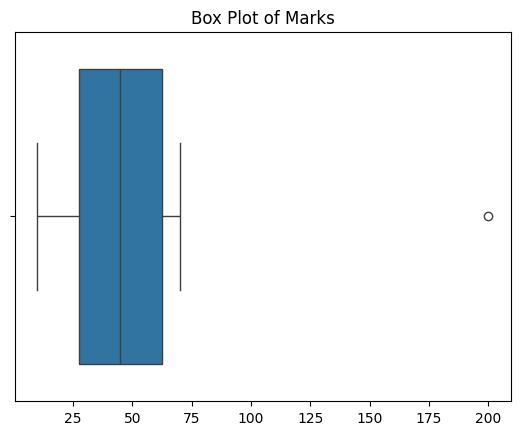

In [22]:
marks = [10,20,30,40,50,60,70,200]
sns.boxplot(x=marks)
plt.title("Box Plot of Marks")
plt.show()

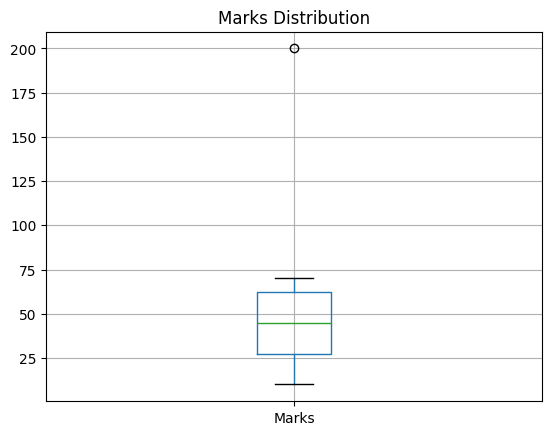

In [23]:
df = pd.DataFrame({
    "Marks":[10,20,30,40,50,60,70,200]
})
df.boxplot(column="Marks")
plt.title("Marks Distribution")
plt.show()

*Interpretation:*

1. The dot (●) is an outlier.
2. The box contains the middle 50% of the observations.
3. The line inside the box is the median.
4. The whiskers represent the non-outlier range of the data.

>


> Q1. Why is a Box Plot preferred over a Histogram in some cases?

A Box Plot provides a quick summary of the data by showing the median, quartiles, IQR, and potential outliers. It is especially useful for comparing multiple distributions side by side.

> Q2. What does the box represent?

The box represents the Interquartile Range (IQR), which contains the middle 50% of the observations.

> Q3. What does the line inside the box represent?

The line inside the box represents the Median (Q2).

> Q4. What do the whiskers represent?

The whiskers extend from the box to the smallest and largest observations that are not classified as outliers.

> 

> *Summary of the day:* 

| Topic | What it Does | Key Formula / Concept | Remember This |
|--------|--------------|----------------------|---------------|
| **Quartiles (Q1, Q2, Q3)** | Divides data into **4 equal parts** | Q1 = 25%, Q2 = Median (50%), Q3 = 75% | **Where is the data?** |
| **Percentiles** | Divides data into **100 equal parts** | k-th Percentile → k% of observations lie below it | **What is the position of an observation?** |
| **Interquartile Range (IQR)** | Measures the spread of the **middle 50%** of the data | $$IQR = Q_3 - Q_1$$ | **Robust measure of spread** |
| **Box Plot** | Graphical summary of the dataset | Five-Number Summary + IQR | **Visualize distribution & detect outliers** |